# Прогнозирование температуры звезды

Вам пришла задача от обсерватории «Небо на ладони»: придумать, как с помощью нейросети определять температуру на поверхности обнаруженных звёзд. Обычно для расчёта температуры учёные пользуются следующими методами:

- Закон смещения Вина.
- Закон Стефана-Больцмана.
- Спектральный анализ.

Каждый из них имеет плюсы и минусы. Обсерватория хочет внедрить технологии машинного обучения для предсказания температуры звёзд, надеясь, что этот метод будет наиболее точным и удобным.

В базе обсерватории есть характеристики уже изученных 240 звёзд.

**Характеристики**
- Относительная светимость L/Lo — светимость звезды относительно Солнца.
- Относительный радиус R/Ro — радиус звезды относительно радиуса Солнца.
- Абсолютная звёздная величина Mv — физическая величина, характеризующая блеск звезды.
- Звёздный цвет (white, red, blue, yellow, yellow-orange и др.) — цвет звезды, который определяют на основе спектрального анализа.

Тип звезды.
- Коричневый карлик	0
- Красный карлик	1
- Белый карлик	2
- Звёзды главной последовательности	3
- Сверхгигант	4
- Гипергигант	5

Абсолютная температура T(K) — температура на поверхности звезды в Кельвинах.

В этом самостоятельном проекте вам необходимо разработать нейронную сеть, которая поможет предсказывать абсолютную температуру на поверхности звезды.

 Светимость Солнца (англ. Average Luminosity of Sun)
 
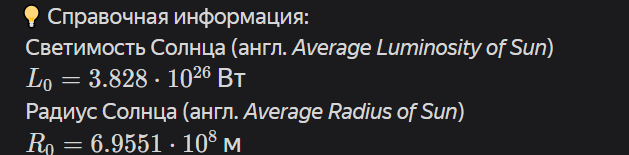

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import chi2_contingency

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error, r2_score

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import torch.optim as optim

import copy
import warnings
warnings.filterwarnings('ignore')

# Настройка отображения
sns.set_style("darkgrid")
sns.set_palette("husl")
pd.set_option('display.max_columns', None)

# print(f'TensorFlow version: {tf.__version__}')


# Шаг 1. Загрузка данных

In [2]:
# Загрузка датасета
df = pd.read_csv('/datasets/6_class.csv')

# Первичный осмотр данных
print("Размер датасета:", df.shape)
print("\n" + "="*50)
print("Случайные  10 строк:")
display(df.sample(10))

print("\n" + "="*50)
print("Информация о данных:")
print(df.info())

print("\n" + "="*50)
print("Статистическое описание:")
display(df.describe())


Размер датасета: (240, 7)

Случайные  10 строк:


,Unnamed: 0,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color
176,176,18000,200000.00000,1045.00000,-8.300,5,Blue
64,64,2935,0.00014,0.11600,18.890,0,Red
57,57,3450,174000.00000,1284.00000,-11.280,5,Red
8,8,2650,0.00069,0.11000,17.450,0,Red
102,102,23000,127000.00000,36.00000,-5.760,4,Blue
213,213,22012,6748.00000,6.64000,-2.550,3,Blue-white
93,93,4980,0.35700,1.13000,4.780,3,Yellowish
148,148,7723,0.00014,0.00878,14.810,2,White
83,83,17200,0.00098,0.01500,12.450,2,Blue White
92,92,4077,0.08500,0.79500,6.228,3,yellowish



Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Unnamed: 0              240 non-null    int64  
 1   Temperature (K)         240 non-null    int64  
 2   Luminosity(L/Lo)        240 non-null    float64
 3   Radius(R/Ro)            240 non-null    float64
 4   Absolute magnitude(Mv)  240 non-null    float64
 5   Star type               240 non-null    int64  
 6   Star color              240 non-null    object 
dtypes: float64(3), int64(3), object(1)
memory usage: 13.2+ KB
None

Статистическое описание:


,Unnamed: 0,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type
count,240.00000,240.000000,240.000000,240.000000,240.000000,240.000000
mean,119.50000,10497.462500,107188.361635,237.157781,4.382396,2.500000
std,69.42622,9552.425037,179432.244940,517.155763,10.532512,1.711394
min,0.00000,1939.000000,0.000080,0.008400,-11.920000,0.000000
25%,59.75000,3344.250000,0.000865,0.102750,-6.232500,1.000000
50%,119.50000,5776.000000,0.070500,0.762500,8.313000,2.500000
75%,179.25000,15055.500000,198050.000000,42.750000,13.697500,4.000000
max,239.00000,40000.000000,849420.000000,1948.500000,20.060000,5.000000


Датасет содержит информацию о 240 звездах с характеристиками: светимость, радиус, абсолютная величина, цвет, тип и температура (целевая переменная).

# Шаг 2. Предобработка и исследотвательский анализ данных

## Проверка пропусков и дубликатов

In [3]:
# Проверка пропущенных значений
print("Пропущенные значения:")
print(df.isnull().sum())
print("\n" + "="*50)

# Проверка дубликатов
print(f"Количество дубликатов: {df.duplicated().sum()}")
print("\n" + "="*50)

# Проверка уникальных значений
print("Уникальные значения 'Star color' до обработки:")
print(df['Star color'].value_counts())

# Приведение к 7 стандартным цветам по Гарвардской классификации
color_mapping = {
    'Blue': 'Blue',
    
    'Blue-white': 'Blue-white',
    'Blue White': 'Blue-white',
    'Blue white': 'Blue-white',
    'Blue-White': 'Blue-white',
    
    'White': 'White',
    'white': 'White',
    'Whitish': 'White',
    
    'yellow-white': 'Yellow-white',
    'Yellowish White': 'Yellow-white',
    'White-Yellow': 'Yellow-white',
    
    'yellowish': 'Yellow',
    'Yellowish': 'Yellow',
    
    'Pale yellow orange': 'Orange',
    'Orange': 'Orange',
    
    'Orange-Red': 'Red',
    'Red': 'Red'
}

df['Star color'] = df['Star color'].str.strip().map(color_mapping)

missing_colors = df[df['Star color'].isna()]
print(f"появившиеся пропуски после маппинга, на случай если какое-то значение в словаре не предусмотрели:")
display(missing_colors)

print("\n" + "="*50)
print("Уникальные значения 'Star color' после обработки:")
print(df['Star color'].value_counts())
print(f"\nКоличество уникальных цветов: {df['Star color'].nunique()}")


Пропущенные значения:
Unnamed: 0                0
Temperature (K)           0
Luminosity(L/Lo)          0
Radius(R/Ro)              0
Absolute magnitude(Mv)    0
Star type                 0
Star color                0
dtype: int64

Количество дубликатов: 0

Уникальные значения 'Star color' до обработки:
Red                   112
Blue                   55
Blue-white             26
Blue White             10
yellow-white            8
White                   7
white                   3
Yellowish White         3
Blue white              3
Orange                  2
yellowish               2
Whitish                 2
Blue                    1
Blue white              1
White-Yellow            1
Orange-Red              1
Yellowish               1
Pale yellow orange      1
Blue-White              1
Name: Star color, dtype: int64
появившиеся пропуски после маппинга, на случай если какое-то значение в словаре не предусмотрели:


,Unnamed: 0,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color



Уникальные значения 'Star color' после обработки:
Red             113
Blue             56
Blue-white       41
Yellow-white     12
White            12
Yellow            3
Orange            3
Name: Star color, dtype: int64

Количество уникальных цветов: 7


## Анализ количественных признаков

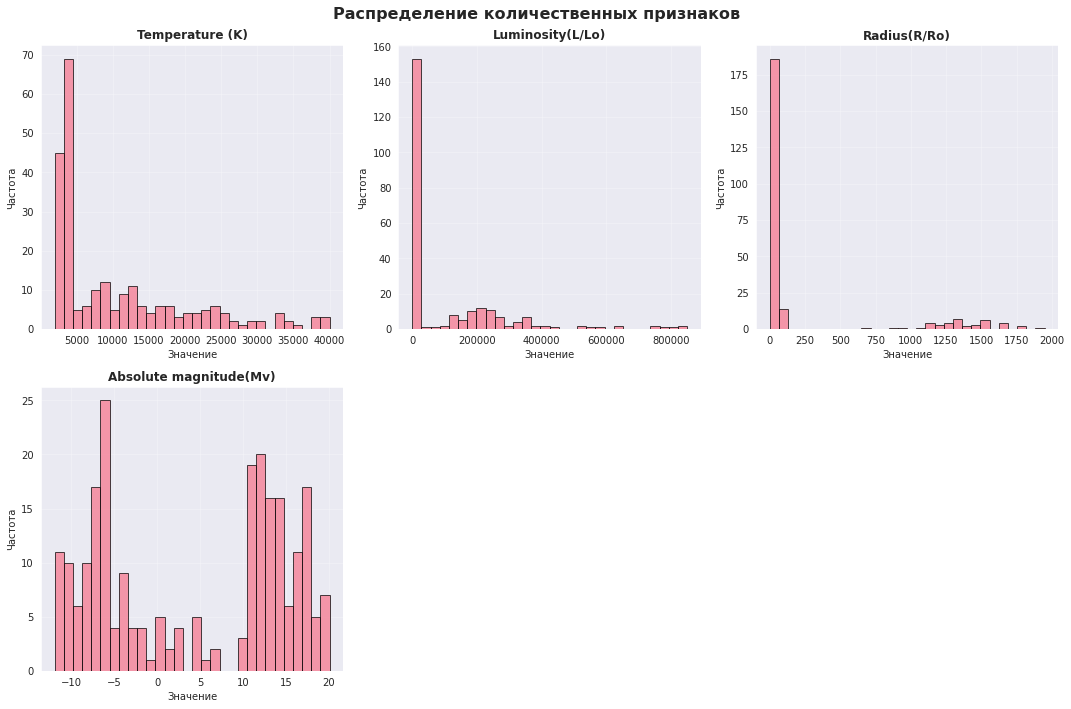

In [4]:
# Распределение количественных признаков
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Распределение количественных признаков', fontsize=16, fontweight='bold')

features = ['Temperature (K)', 'Luminosity(L/Lo)', 'Radius(R/Ro)', 'Absolute magnitude(Mv)']

for idx, col in enumerate(features):
    row = idx // 3
    col_idx = idx % 3
    axes[row, col_idx].hist(df[col], bins=30, edgecolor='black', alpha=0.7)
    axes[row, col_idx].set_title(col, fontweight='bold')
    axes[row, col_idx].set_xlabel('Значение')
    axes[row, col_idx].set_ylabel('Частота')
    axes[row, col_idx].grid(True, alpha=0.3)

# Удаление лишних осей
axes[1, 1].axis('off')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()


## Корреляционный анализ

In [5]:
# Функция для вычисления Eta-squared
def eta_squared(categorical, continuous):
    """
    Вычисление Eta-squared для связи категориального и непрерывного признака
    """
    categories = categorical.unique()
    groups = [continuous[categorical == cat] for cat in categories]
    
    # ANOVA F-statistic
    f_stat, p_value = stats.f_oneway(*groups)
    
    # Общая сумма квадратов
    grand_mean = continuous.mean()
    ss_total = sum((continuous - grand_mean) ** 2)
    
    # Межгрупповая сумма квадратов
    ss_between = sum(len(group) * (group.mean() - grand_mean) ** 2 for group in groups)
    
    # Eta-squared
    eta_sq = ss_between / ss_total
    
    return eta_sq

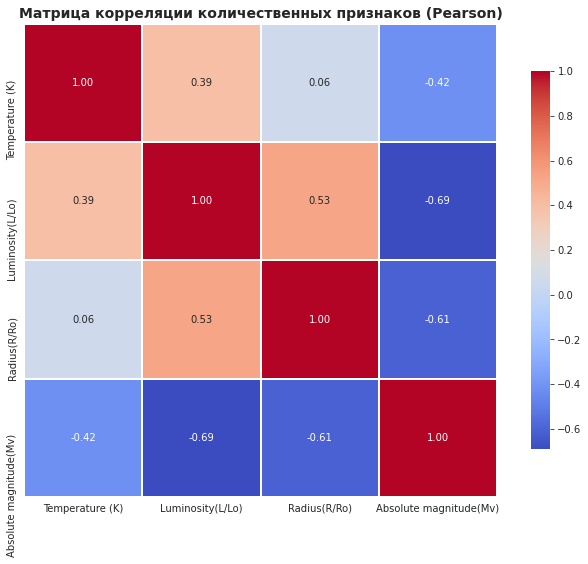

In [6]:
# 1. Корреляция Пирсона для количественных признаков
plt.figure(figsize=(10, 8))
correlation_matrix = df[['Temperature (K)', 'Luminosity(L/Lo)', 'Radius(R/Ro)', 
                          'Absolute magnitude(Mv)']].corr()

sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Матрица корреляции количественных признаков (Pearson)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [7]:
# 2. Вычисление Eta-squared для категориальных признаков
eta_sq_type = eta_squared(df['Star type'], df['Temperature (K)'])
eta_sq_color = eta_squared(df['Star color'], df['Temperature (K)'])

In [8]:
# 3. Объединенная таблица всех корреляций
print("="*70)
print("КОРРЕЛЯЦИЯ ВСЕХ ПРИЗНАКОВ С ЦЕЛЕВОЙ ПЕРЕМЕННОЙ Temperature (K)")
print("="*70)

# Создание сводной таблицы
all_correlations = pd.DataFrame({
    'Признак': ['Luminosity(L/Lo)', 'Radius(R/Ro)', 'Absolute magnitude(Mv)', 
                'Star type', 'Star color'],
    'Коэффициент': [
        correlation_matrix.loc['Luminosity(L/Lo)', 'Temperature (K)'],
        correlation_matrix.loc['Radius(R/Ro)', 'Temperature (K)'],
        correlation_matrix.loc['Absolute magnitude(Mv)', 'Temperature (K)'],
        eta_sq_type,
        eta_sq_color
    ],
    'Тип корреляции': ['Pearson', 'Pearson', 'Pearson', 'Eta-squared', 'Eta-squared']
})

# Сортировка по абсолютному значению коэффициента
all_correlations['Абс. значение'] = all_correlations['Коэффициент'].abs()
all_correlations = all_correlations.sort_values('Абс. значение', ascending=False)
all_correlations = all_correlations.drop('Абс. значение', axis=1)

print(all_correlations.to_string(index=False))

print("\n" + "="*70)
print("ИНТЕРПРЕТАЦИЯ:")
print("="*70)
print("Pearson correlation: -1 до 1 (чем ближе к ±1, тем сильнее линейная связь)")
print("Eta-squared: 0 до 1 (доля дисперсии, объясняемая категориальным признаком)")
print("  • 0.01-0.06: слабая связь")
print("  • 0.06-0.14: умеренная связь")
print("  • >0.14: сильная связь")

КОРРЕЛЯЦИЯ ВСЕХ ПРИЗНАКОВ С ЦЕЛЕВОЙ ПЕРЕМЕННОЙ Temperature (K)
               Признак  Коэффициент Тип корреляции
            Star color     0.688142    Eta-squared
Absolute magnitude(Mv)    -0.420261        Pearson
      Luminosity(L/Lo)     0.393404        Pearson
             Star type     0.320791    Eta-squared
          Radius(R/Ro)     0.064216        Pearson

ИНТЕРПРЕТАЦИЯ:
Pearson correlation: -1 до 1 (чем ближе к ±1, тем сильнее линейная связь)
Eta-squared: 0 до 1 (доля дисперсии, объясняемая категориальным признаком)
  • 0.01-0.06: слабая связь
  • 0.06-0.14: умеренная связь
  • >0.14: сильная связь


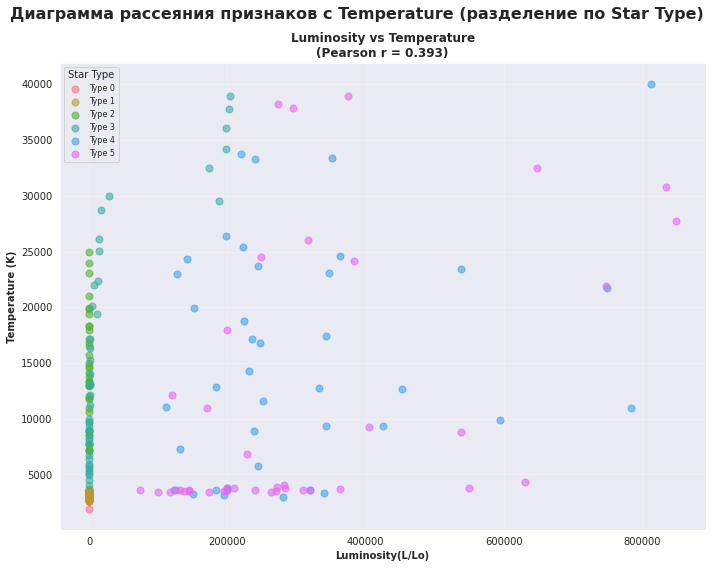

In [9]:
# 4. Диаграмма рассеяния с разделением по Star Type
fig, ax = plt.subplots(figsize=(10, 8))
fig.suptitle('Диаграмма рассеяния признаков с Temperature (разделение по Star Type)', 
             fontsize=16, fontweight='bold')

# Создаем палитру цветов для типов звезд
star_types = sorted(df['Star type'].unique())
colors = sns.color_palette("husl", len(star_types))
type_colors = {star_type: colors[i] for i, star_type in enumerate(star_types)}

# График: Luminosity vs Temperature
for star_type in star_types:
    mask = df['Star type'] == star_type
    ax.scatter(df[mask]['Luminosity(L/Lo)'], df[mask]['Temperature (K)'], 
              c=[type_colors[star_type]], label=f'Type {star_type}', alpha=0.6, s=50)
ax.set_xlabel('Luminosity(L/Lo)', fontweight='bold')
ax.set_ylabel('Temperature (K)', fontweight='bold')
ax.set_title(f'Luminosity vs Temperature\n(Pearson r = {correlation_matrix.loc["Luminosity(L/Lo)", "Temperature (K)"]:.3f})', 
             fontweight='bold')
ax.legend(title='Star Type', loc='best', fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
# График 2: Radius vs Temperature
for star_type in star_types:
    mask = df['Star type'] == star_type
    axes[0, 1].scatter(df[mask]['Radius(R/Ro)'], df[mask]['Temperature (K)'], 
                      c=[type_colors[star_type]], label=f'Type {star_type}', alpha=0.6, s=50)
axes[0, 1].set_xlabel('Radius(R/Ro)', fontweight='bold')
axes[0, 1].set_ylabel('Temperature (K)', fontweight='bold')
axes[0, 1].set_title(f'Radius vs Temperature\n(Pearson r = {correlation_matrix.loc["Radius(R/Ro)", "Temperature (K)"]:.3f})', 
                     fontweight='bold')
axes[0, 1].legend(title='Star Type', loc='best', fontsize=8)
axes[0, 1].grid(True, alpha=0.3)

In [11]:
# График 3: Absolute magnitude vs Temperature
for star_type in star_types:
    mask = df['Star type'] == star_type
    axes[1, 0].scatter(df[mask]['Absolute magnitude(Mv)'], df[mask]['Temperature (K)'], 
                      c=[type_colors[star_type]], label=f'Type {star_type}', alpha=0.6, s=50)
axes[1, 0].set_xlabel('Absolute magnitude(Mv)', fontweight='bold')
axes[1, 0].set_ylabel('Temperature (K)', fontweight='bold')
axes[1, 0].set_title(f'Absolute magnitude vs Temperature\n(Pearson r = {correlation_matrix.loc["Absolute magnitude(Mv)", "Temperature (K)"]:.3f})', 
                     fontweight='bold')
axes[1, 0].legend(title='Star Type', loc='best', fontsize=8)
axes[1, 0].grid(True, alpha=0.3)

In [12]:
# График 4: Boxplot Star Type vs Temperature
df.boxplot(column='Temperature (K)', by='Star type', ax=axes[1, 1], grid=False)
axes[1, 1].set_title(f'Temperature по типу звезды\n(Eta² = {eta_sq_type:.4f})', 
                     fontweight='bold')
axes[1, 1].set_xlabel('Star Type', fontweight='bold')
axes[1, 1].set_ylabel('Temperature (K)', fontweight='bold')
axes[1, 1].get_figure().suptitle('')

plt.tight_layout()
plt.show()

<Figure size 432x288 with 0 Axes>

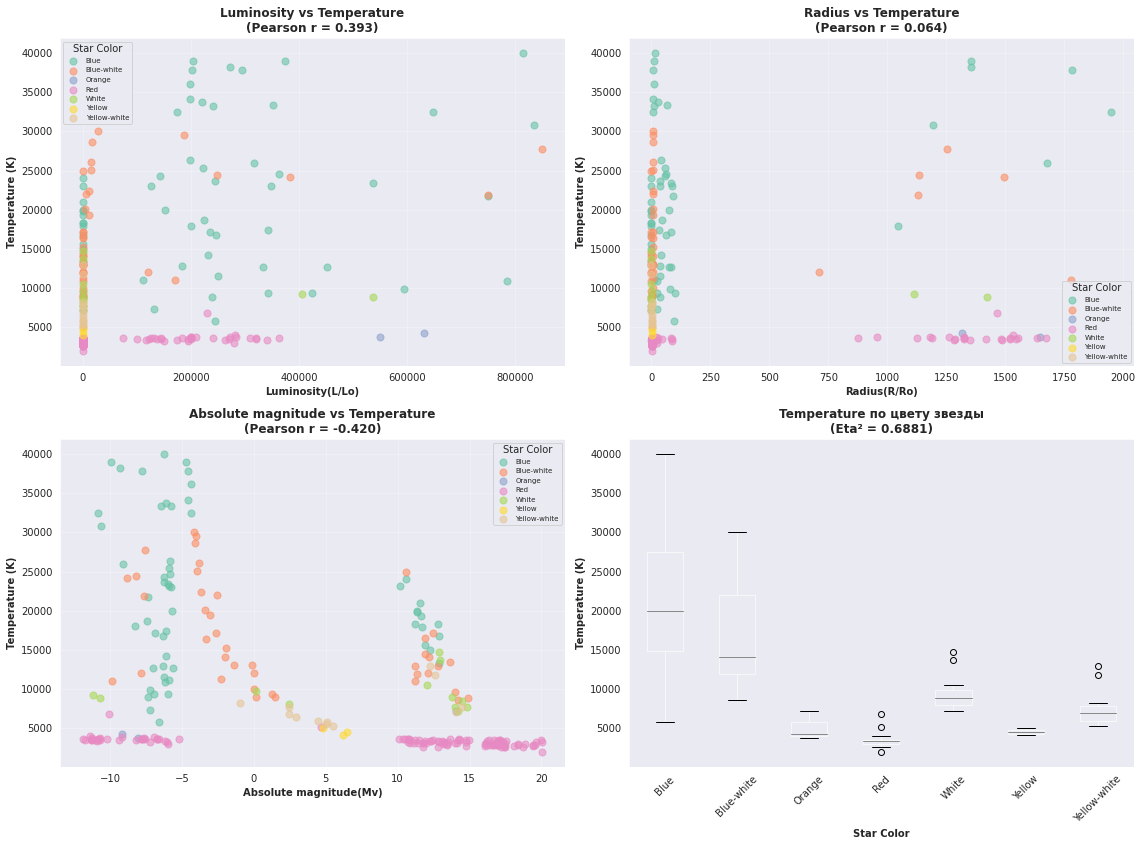

In [13]:
# 5. Диаграммы рассеяния с разделением по Star Color
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Диаграммы рассеяния признаков с Temperature (разделение по Star Color)', 
             fontsize=16, fontweight='bold', y=1.00)

# Создаем палитру цветов для цветов звезд
star_colors_unique = sorted(df['Star color'].dropna().unique())
colors_palette = sns.color_palette("Set2", len(star_colors_unique))
color_mapping = {star_color: colors_palette[i] for i, star_color in enumerate(star_colors_unique)}

# График 1: Luminosity vs Temperature
for star_color in star_colors_unique:
    mask = df['Star color'] == star_color
    axes[0, 0].scatter(df[mask]['Luminosity(L/Lo)'], df[mask]['Temperature (K)'], 
                      c=[color_mapping[star_color]], label=star_color, alpha=0.6, s=50)
axes[0, 0].set_xlabel('Luminosity(L/Lo)', fontweight='bold')
axes[0, 0].set_ylabel('Temperature (K)', fontweight='bold')
axes[0, 0].set_title(f'Luminosity vs Temperature\n(Pearson r = {correlation_matrix.loc["Luminosity(L/Lo)", "Temperature (K)"]:.3f})', 
                     fontweight='bold')
axes[0, 0].legend(title='Star Color', loc='best', fontsize=7)
axes[0, 0].grid(True, alpha=0.3)

# График 2: Radius vs Temperature
for star_color in star_colors_unique:
    mask = df['Star color'] == star_color
    axes[0, 1].scatter(df[mask]['Radius(R/Ro)'], df[mask]['Temperature (K)'], 
                      c=[color_mapping[star_color]], label=star_color, alpha=0.6, s=50)
axes[0, 1].set_xlabel('Radius(R/Ro)', fontweight='bold')
axes[0, 1].set_ylabel('Temperature (K)', fontweight='bold')
axes[0, 1].set_title(f'Radius vs Temperature\n(Pearson r = {correlation_matrix.loc["Radius(R/Ro)", "Temperature (K)"]:.3f})', 
                     fontweight='bold')
axes[0, 1].legend(title='Star Color', loc='best', fontsize=7)
axes[0, 1].grid(True, alpha=0.3)

# График 3: Absolute magnitude vs Temperature
for star_color in star_colors_unique:
    mask = df['Star color'] == star_color
    axes[1, 0].scatter(df[mask]['Absolute magnitude(Mv)'], df[mask]['Temperature (K)'], 
                      c=[color_mapping[star_color]], label=star_color, alpha=0.6, s=50)
axes[1, 0].set_xlabel('Absolute magnitude(Mv)', fontweight='bold')
axes[1, 0].set_ylabel('Temperature (K)', fontweight='bold')
axes[1, 0].set_title(f'Absolute magnitude vs Temperature\n(Pearson r = {correlation_matrix.loc["Absolute magnitude(Mv)", "Temperature (K)"]:.3f})', 
                     fontweight='bold')
axes[1, 0].legend(title='Star Color', loc='best', fontsize=7)
axes[1, 0].grid(True, alpha=0.3)

# График 4: Boxplot Star Color vs Temperature
df_clean = df.dropna(subset=['Star color'])
df_clean.boxplot(column='Temperature (K)', by='Star color', ax=axes[1, 1], grid=False)

axes[1, 1].set_title(f'Temperature по цвету звезды\n(Eta² = {eta_sq_color:.4f})', 
                     fontweight='bold')
axes[1, 1].set_xlabel('Star Color', fontweight='bold')
axes[1, 1].set_ylabel('Temperature (K)', fontweight='bold')
axes[1, 1].tick_params(axis='x', rotation=45)
plt.suptitle('')

plt.tight_layout()
plt.show()


PAIRPLOT: Взаимосвязи между всеми количественными признаками


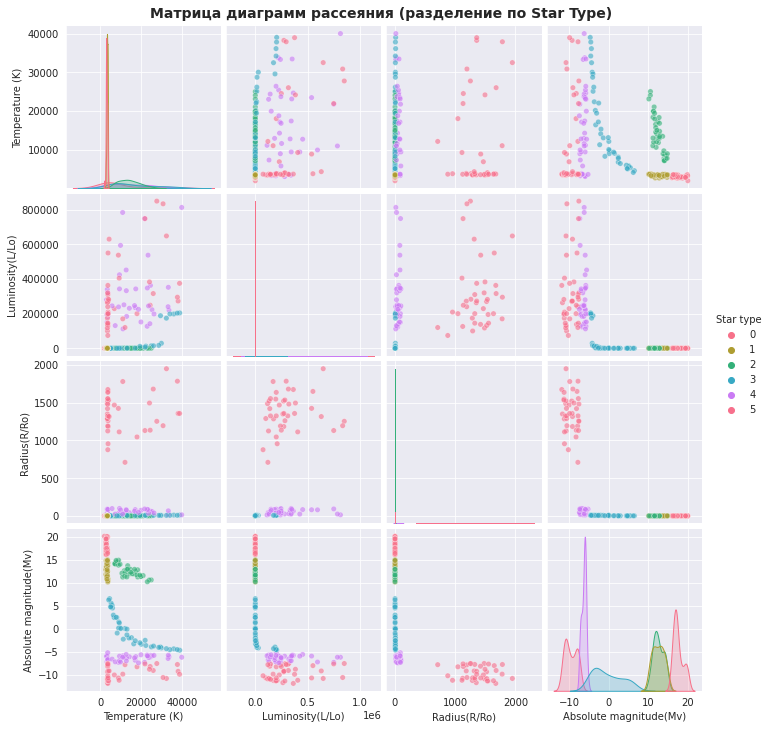

In [14]:
# 6. Pairplot для всех количественных признаков с разделением по Star Type
print("\n" + "="*70)
print("PAIRPLOT: Взаимосвязи между всеми количественными признаками")
print("="*70)

# Создаем копию данных для pairplot
df_pairplot = df[['Temperature (K)', 'Luminosity(L/Lo)', 'Radius(R/Ro)', 
                   'Absolute magnitude(Mv)', 'Star type']].copy()

# Pairplot с разделением по Star Type
g = sns.pairplot(df_pairplot, hue='Star type', palette='husl', 
                 diag_kind='kde', plot_kws={'alpha': 0.6, 's': 30},
                 height=2.5)
g.fig.suptitle('Матрица диаграмм рассеяния (разделение по Star Type)', 
               y=1.01, fontsize=14, fontweight='bold')
plt.show()


ПОЛНАЯ МАТРИЦА КОРРЕЛЯЦИЙ (количественные + категориальные)


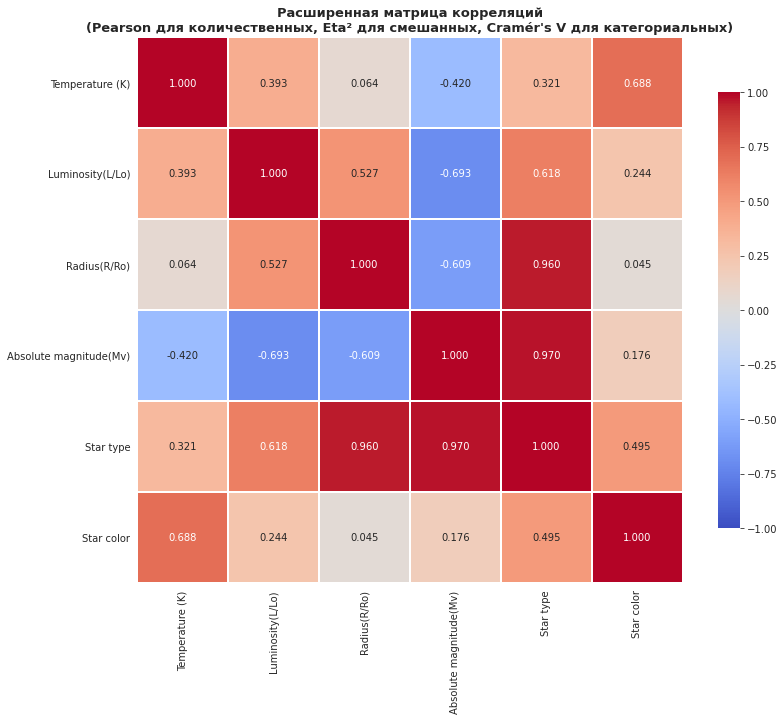


Легенда:
  • Количественные ↔ Количественные: Pearson correlation (-1 до 1)
  • Категориальные ↔ Количественные: Eta-squared (0 до 1)
  • Категориальные ↔ Категориальные: Cramér's V (0 до 1)


In [15]:
# 7. Корреляция между всеми признаками (включая категориальные через Eta-squared)
print("\n" + "="*70)
print("ПОЛНАЯ МАТРИЦА КОРРЕЛЯЦИЙ (количественные + категориальные)")
print("="*70)

# Создаем расширенную матрицу корреляций
features = ['Temperature (K)', 'Luminosity(L/Lo)', 'Radius(R/Ro)', 
            'Absolute magnitude(Mv)', 'Star type', 'Star color']

# Инициализируем матрицу
extended_corr_matrix = pd.DataFrame(index=features, columns=features, dtype=float)

# Заполняем корреляции Пирсона для количественных признаков
quant_features = ['Temperature (K)', 'Luminosity(L/Lo)', 'Radius(R/Ro)', 'Absolute magnitude(Mv)']
for i, feat1 in enumerate(quant_features):
    for j, feat2 in enumerate(quant_features):
        extended_corr_matrix.loc[feat1, feat2] = correlation_matrix.loc[feat1, feat2]

# Заполняем Eta-squared для категориальных признаков
cat_features = ['Star type', 'Star color']
for cat_feat in cat_features:
    for quant_feat in quant_features:
        eta_sq = eta_squared(df[cat_feat], df[quant_feat])
        extended_corr_matrix.loc[cat_feat, quant_feat] = eta_sq
        extended_corr_matrix.loc[quant_feat, cat_feat] = eta_sq
        

def cramers_v(x, y):
    """Вычисление Cramér's V для двух категориальных переменных"""
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    min_dim = min(confusion_matrix.shape) - 1
    return np.sqrt(chi2 / (n * min_dim))

extended_corr_matrix.loc['Star type', 'Star color'] = cramers_v(df['Star type'], df['Star color'])
extended_corr_matrix.loc['Star color', 'Star type'] = extended_corr_matrix.loc['Star type', 'Star color']
extended_corr_matrix.loc['Star type', 'Star type'] = 1.0
extended_corr_matrix.loc['Star color', 'Star color'] = 1.0

# Визуализация расширенной матрицы корреляций
plt.figure(figsize=(12, 10))
sns.heatmap(extended_corr_matrix.astype(float), annot=True, fmt='.3f', cmap='coolwarm', 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            vmin=-1, vmax=1, center=0)
plt.title('Расширенная матрица корреляций\n(Pearson для количественных, Eta² для смешанных, Cramér\'s V для категориальных)', 
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nЛегенда:")
print("  • Количественные ↔ Количественные: Pearson correlation (-1 до 1)")
print("  • Категориальные ↔ Количественные: Eta-squared (0 до 1)")
print("  • Категориальные ↔ Категориальные: Cramér's V (0 до 1)")




<div class="alert alert-danger">
<s><b>😔 Необходимо исправить:</b> Из ячейки нужно убрать импорт (они все должны быть в начале работы)</s>
</div>

 <div class="alert alert-info"> <b>🎓 Комментарий студента:</b>Исправлено</div>

<div class="alert alert-warning">
<b>🤔 Рекомендация:</b> Проще же было посмотреть Phik
</div>

 <div class="alert alert-info"> <b>🎓 Комментарий студента:</b>Да, согласен, я помню про него, и одно время им восторгался и всем про него рассказывал, но потом почему-то постоянно возникала какая-то ошибка несовместимости, пробовал кучу разных версий библиотек но этот фик все равно не работал... и что ему нужно, что раньше он вроде работает, потом не работает, при том что делаешь вроде то же самое - не понятно...

Я уже привыкал использовать только phik, но тут началось стандартное традиционное за что мы люим свою работу: то работает, то ничего не менялось вроде - не работает, и по ходу запоминать что-то нет смысла и искать в чем-то смысл и логику, сегодня работает, завтра - нет.. ошибку мне эту тогда так и не удалось решить</div>

## Анализ категориальных признаков

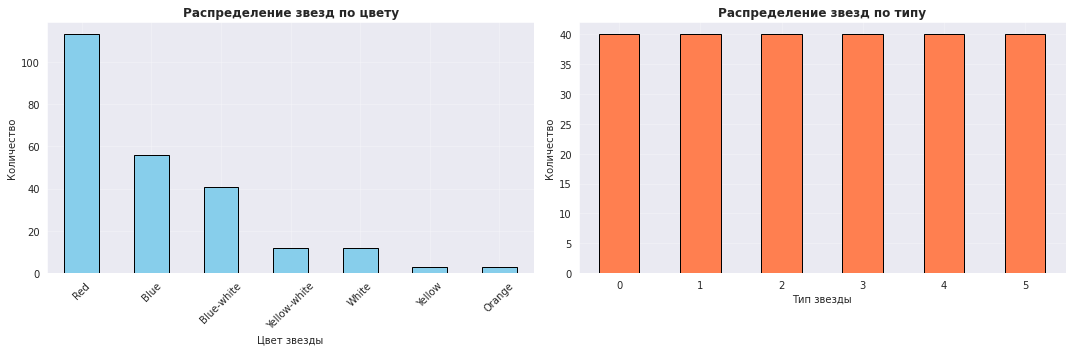

In [16]:
# Распределение по цвету звезды
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# График 1: Количество звезд по цвету
df['Star color'].value_counts().plot(kind='bar', ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_title('Распределение звезд по цвету', fontweight='bold')
axes[0].set_xlabel('Цвет звезды')
axes[0].set_ylabel('Количество')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3)

# График 2: Количество звезд по типу
df['Star type'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Распределение звезд по типу', fontweight='bold')
axes[1].set_xlabel('Тип звезды')
axes[1].set_ylabel('Количество')
axes[1].tick_params(axis='x', rotation=0)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Связь температуры с категориальными признаками

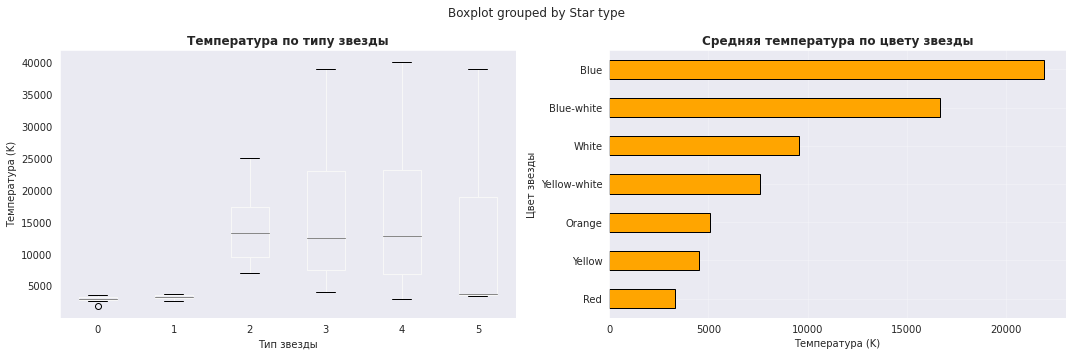

In [17]:
# Температура в зависимости от типа звезды
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Boxplot по типу звезды
df.boxplot(column='Temperature (K)', by='Star type', ax=axes[0], grid=False)
axes[0].set_title('Температура по типу звезды', fontweight='bold')
axes[0].set_xlabel('Тип звезды')
axes[0].set_ylabel('Температура (K)')
plt.sca(axes[0])
plt.xticks(rotation=0)

# Средняя температура по цвету
temp_by_color = df.groupby('Star color')['Temperature (K)'].mean().sort_values()
temp_by_color.plot(kind='barh', ax=axes[1], color='orange', edgecolor='black')
axes[1].set_title('Средняя температура по цвету звезды', fontweight='bold')
axes[1].set_xlabel('Температура (K)')
axes[1].set_ylabel('Цвет звезды')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Вывод по EDA:

- Датасет не содержит пропусков и дубликатов

- Температура имеет сильную корреляцию с абсолютной величиной и типом звезды

- Различные типы звезд имеют разные диапазоны температур

- Цвет звезды также связан с температурой (красные - холоднее, синие - горячее)

# Построение базовой нейронной сети

## Шаг 3. Подготовка данных к построению модели

Кодирование категориальных признаков

In [18]:
# --- 1. Подготовка данных ---
# Удаление ненужного столбца
df = df.drop('Unnamed: 0', axis=1)

# Разделение на признаки и целевую переменную
X = df.drop('Temperature (K)', axis=1)
y = df['Temperature (K)']

# --- 2. Разделение на train и test (ДО препроцессинга) ---
# Это критически важный шаг для предотвращения утечки данных
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=df['Star color'] # Ход конем: стратифицируем не целевой непрерывный признак, а по группам категорий цвета
)

print(f"Размер train: {X_train.shape[0]} ({X_train.shape[0]/len(df)*100:.1f}%)")
print(f"Размер test: {X_test.shape[0]} ({X_test.shape[0]/len(df)*100:.1f}%)")

# --- 3. Препроцессинг (ТОЛЬКО для train) ---
# Определяем колонку для кодирования
categorical_features = ['Star color']

# Создаем ColumnTransformer. Обучаем его ТОЛЬКО на X_train!
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse=False), categorical_features)  # drop='first', - убрал
    ],
    remainder='passthrough' # Остальные колонки (числовые) передаем как есть
)

# Применяем кодирование к обучающей выборке
X_train_encoded = preprocessor.fit_transform(X_train)

# Применяем ТОЛЬКО трансформацию к тестовой выборке (без обучения!)
X_test_encoded = preprocessor.transform(X_test)

# Масштабирование (стандартизация)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded) # Обучаем на трейне
X_test_scaled = scaler.transform(X_test_encoded)       # Применяем к тесту

# --- 4. Преобразование в тензоры PyTorch ---
# В PyTorch тензоры создаются из numpy-массивов (которые возвращает sklearn)
X_train_tensor = torch.FloatTensor(X_train_scaled)
y_train_tensor = torch.FloatTensor(y_train.values).reshape(-1, 1)

X_test_tensor = torch.FloatTensor(X_test_scaled)
y_test_tensor = torch.FloatTensor(y_test.values).reshape(-1, 1)

# Создание DataLoader для обучения
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

print(f"\nРазмер train tensor: {X_train_tensor.shape}")
print(f"Размер test tensor: {X_test_tensor.shape}")

Размер train: 192 (80.0%)
Размер test: 48 (20.0%)

Размер train tensor: torch.Size([192, 11])
Размер test tensor: torch.Size([48, 11])


    - сначала делю на выборки, потом кодирую (так и делали же всегда)
    - применил стратификацию (как я упустил и забыл такую элементарную и обязательную вещь..)
    - в OHE добавил handle_unknown='ignore' для отсутсвующих категорий

    Мы решаем задачу регересси (предсказываем температуру - много разных случайных цифр - непрерывный признак), но пытаемся использовать  стратификацию, которая используется при задачах классификации. Значит стратифицровать надо не по целевому признаку, а по категориям - по цвету звезды. Я сам задал, сам ответил походу  на свой вопрос..

## Создание Dataset для PyTorch

In [19]:
# 1. Создаем датасеты только для train и test
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# 2. Создаем DataLoader
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# 3. Выводим информацию о количестве батчей
print(f"Train batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")


Train batches: 12
Test batches: 3


# Шаг 4. Построение простой модели нейронной сети — Baseline

### Создание архитектуры нейронной сети

- Создайте класс для задания архитектуры нейронной сети.
- Самостоятельно выберите количество скрытых слоёв, количество нейронов на них, функции активации на скрытых и выходном слоях. 
- Попробуйте и сравните несколько подобных комбинаций.
- Проведите обучение нейронной сети:
- Создайте функцию для обучения нейронной сети.
- Проведите обучение модели.
- Постройте график «Факт — Прогноз», где по горизонтальной оси будут отложены условные номера звёзд, а по вертикальной — температура в Кельвинах.

In [20]:
class BaselineModel(nn.Module):
    def __init__(self, input_size):
        super(BaselineModel, self).__init__()
        self.fc1 = nn.Linear(input_size, 512)
        self.bn1 = nn.BatchNorm1d(512)
        
        self.fc2 = nn.Linear(512, 256)
        self.bn2 = nn.BatchNorm1d(256)
        
        self.fc3 = nn.Linear(256, 128)
        self.bn3 = nn.BatchNorm1d(128)
        
        self.fc4 = nn.Linear(128, 1)
        self.leaky_relu = nn.LeakyReLU(0.2)
    
    def forward(self, x):
        x = self.leaky_relu(self.bn1(self.fc1(x)))
        
        x = self.leaky_relu(self.bn2(self.fc2(x)))
        
        x = self.leaky_relu(self.bn3(self.fc3(x)))
        
        x = self.fc4(x)
        return x

# Инициализация модели
input_size = X_train_tensor.shape[1]
model_baseline = BaselineModel(input_size)
print(model_baseline)


BaselineModel(
  (fc1): Linear(in_features=11, out_features=512, bias=True)
  (bn1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (bn2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=256, out_features=128, bias=True)
  (bn3): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc4): Linear(in_features=128, out_features=1, bias=True)
  (leaky_relu): LeakyReLU(negative_slope=0.2)
)


### Обучение базовой модели

In [21]:
def train_model(model, train_loader, X_test, y_test, criterion, optimizer, epochs=1000):
    """
    Обучение модели с отслеживанием ошибки на тестовой выборке.
    
    Параметры:
        model: Нейросетевая модель.
        train_loader: DataLoader с обучающими данными.
        X_test, y_test: Тензоры тестовых данных (для оценки качества).
        criterion: Функция потерь (например, nn.MSELoss()).
        optimizer: Оптимизатор (например, torch.optim.Adam).
        epochs: Количество эпох обучения.
        
    Возвращает:
        model: лучшая модель по rmse
        train_losses: Список средних ошибок на обучающей выборке по эпохам.
        test_losses: Список ошибок на тестовой выборке по эпохам.
        
    """
    
    train_losses = []
    test_losses = []
    
    # --- Переменные для отслеживания лучшей модели ---
    best_rmse = float('inf') # Начинаем с бесконечности
    best_model_state = None
    
    for epoch in range(epochs):
        # --- ЭТАП 1: Обучение (Train) ---
        model.train()
        total_train_loss = 0
        
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            predictions = model(X_batch)
            loss = criterion(predictions, y_batch)
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()
        
        avg_train_loss = total_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        
        # --- ЭТАП 2: Тестирование и проверка на лучшую модель ---
        model.eval()
        with torch.no_grad():
            test_predictions = model(X_test)
            test_loss = criterion(test_predictions, y_test).item()
        
        test_losses.append(test_loss)
        
        # Вычисляем RMSE для удобства сравнения
        current_rmse = np.sqrt(test_loss)
        
        # --- ЛОГИКА СОХРАНЕНИЯ ЛУЧШЕЙ МОДЕЛИ ---
        # Сохраняем модель, если текущий RMSE меньше лучшего и меньше порога 4500
        if current_rmse < best_rmse and current_rmse < 4500:
            best_rmse = current_rmse
            
            # Используем deepcopy, чтобы сохранить именно состояние весов,
            # а не ссылку на объект модели, которая продолжит меняться.
            best_model_state = copy.deepcopy(model.state_dict())
        
        # Выводим прогресс каждые 100 эпох
        if (epoch + 1) % 100 == 0:
            print(f'Epoch [{epoch+1}/{epochs}] | Train Loss: {avg_train_loss:.4f} | Test RMSE: {current_rmse:.2f}')
    
    print("\nОбучение завершено!")
    
    # --- ФИНАЛЬНЫЙ ШАГ: Загрузка лучших весов ---
    if best_model_state is not None:
        print(f"Загрузка состояния лучшей модели с RMSE: {best_rmse:.2f}")
        model.load_state_dict(best_model_state)
    else:
        print("Модель не достигла порога RMSE < 4500. Загружено состояние последней эпохи.")
    
    return model, train_losses, test_losses



In [22]:
# --- Обучение ---
input_size = X_train_scaled.shape[1]
print(f"Количество признаков после кодирования: {input_size}")

model_baseline = BaselineModel(input_size=input_size)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_baseline.parameters(), lr=0.002, weight_decay=1e-5)
# scheduler больше не нужен для этой функции

print("Обучение Baseline модели...")

best_model, train_losses_baseline, test_losses_baseline = train_model(
    model_baseline,
    train_loader,
    X_test_tensor, y_test_tensor,
    criterion,
    optimizer,
    epochs=2000  
)

Количество признаков после кодирования: 11
Обучение Baseline модели...
Epoch [100/2000] | Train Loss: 175619605.3333 | Test RMSE: 9655.80
Epoch [200/2000] | Train Loss: 92846252.3333 | Test RMSE: 6966.33
Epoch [300/2000] | Train Loss: 40080217.2500 | Test RMSE: 4815.95
Epoch [400/2000] | Train Loss: 19784403.7708 | Test RMSE: 3856.44
Epoch [500/2000] | Train Loss: 18455355.7500 | Test RMSE: 3940.54
Epoch [600/2000] | Train Loss: 25977195.8333 | Test RMSE: 4371.90
Epoch [700/2000] | Train Loss: 14041314.2917 | Test RMSE: 4471.26
Epoch [800/2000] | Train Loss: 15449132.0417 | Test RMSE: 4219.56
Epoch [900/2000] | Train Loss: 16337616.9167 | Test RMSE: 4334.38
Epoch [1000/2000] | Train Loss: 15107447.8333 | Test RMSE: 4222.04
Epoch [1100/2000] | Train Loss: 12932239.5208 | Test RMSE: 3861.99
Epoch [1200/2000] | Train Loss: 12035310.6146 | Test RMSE: 4217.72
Epoch [1300/2000] | Train Loss: 12420963.7917 | Test RMSE: 4212.01
Epoch [1400/2000] | Train Loss: 14914607.2917 | Test RMSE: 4098.05

Каким-то чудесным образом RMSE сразу достиг цели!! но как нам это удалось?
    
    - я лучше почистил словарь цветов (до этого не учитывал пробелы после названия цвета, и два цвета не сопоставлялось с пробелами после названия цвета)
    - при разделении выборок оставил две выборки тренировочную и тестовую, убрал валидационную, за которую все раньше обязательно топили
    - убрал шедулер
    - сдедал сначала все-таки разделение на выборки, а потом кодирование OHE..
    - ну и эпохи увеличил с 1000 до 2000.. но было в рабочем моменте и 1500
    
Мы превзошли целевой показатель 4500.

### Оценка базовой модели

Baseline Model RMSE: 3608.17
Baseline Model R²: 0.7282


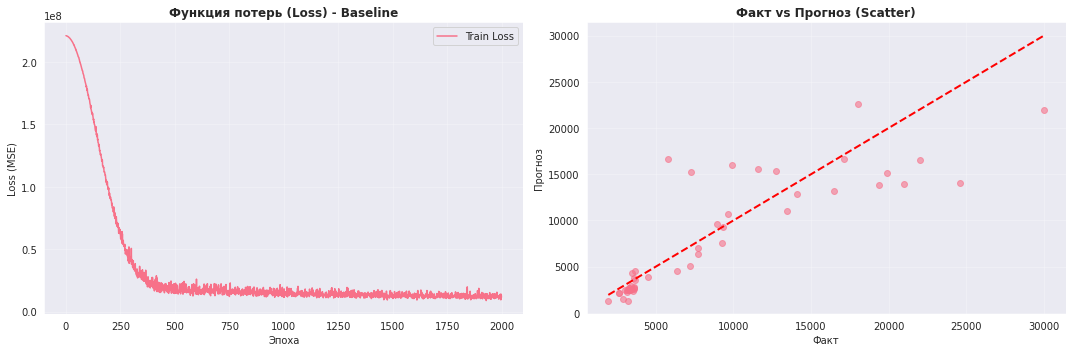

In [23]:
# Оценка базовой модели
model_baseline.eval()
with torch.no_grad():
    y_pred_baseline = model_baseline(X_test_tensor).numpy()

rmse_baseline = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
r2_baseline = r2_score(y_test, y_pred_baseline)

print(f"Baseline Model RMSE: {rmse_baseline:.2f}")
print(f"Baseline Model R²: {r2_baseline:.4f}")

# График потерь
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss
axes[0].plot(train_losses_baseline, label='Train Loss')
axes[0].set_title('Функция потерь (Loss) - Baseline', fontweight='bold')
axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('Loss (MSE)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Scatter plot
axes[1].scatter(y_test.values, y_pred_baseline, alpha=0.6)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_title('Факт vs Прогноз (Scatter)', fontweight='bold')
axes[1].set_xlabel('Факт')
axes[1].set_ylabel('Прогноз')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



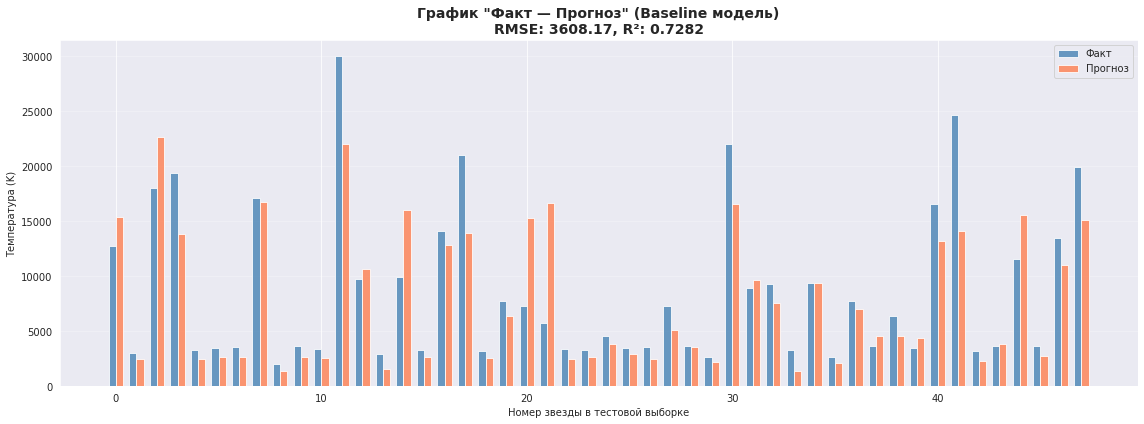

In [24]:
# Используем всю длину тестовой выборки
n_samples = len(y_test)
x_axis = range(n_samples)

plt.figure(figsize=(16, 6))
width = 0.35

# Передаем в bar() полные массивы данных, а не срезы [:n_samples]
plt.bar([i - width/2 for i in x_axis], y_test.values, width,
        label='Факт', alpha=0.8, color='steelblue')
plt.bar([i + width/2 for i in x_axis], y_pred_baseline.flatten(), width,
        label='Прогноз', alpha=0.8, color='coral')

plt.title(f'График "Факт — Прогноз" (Baseline модель)\nRMSE: {rmse_baseline:.2f}, R²: {r2_baseline:.4f}',
          fontsize=14, fontweight='bold')
plt.xlabel('Номер звезды в тестовой выборке')
plt.ylabel('Температура (K)')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## Вывод по Baseline модели:

- Базовая модель показывает хорошие результаты

- RMSE реврсходит целевые значения 4500

- Модель хорошо улавливает общие тренды в данных

- Есть потенциал для улучшения через оптимизацию гиперпараметров

# Шаг 5. Улучшение нейронной сети

- Создайте решение с перебором параметров нейросети. Список параметров для перебора должен включать как минимум «dropout» и «размер батча». Архитектуру нейронной сети: количество слоёв, нейронов, вид функции активации — оставьте как в Baseline, чтобы сравнить результат.
- Проведите обучение нейронной сети. Выведите метрику RMSE и график «Факт — прогноз». **Метрика RMSE не должна превышать 4500**.
- Сделайте вывод. Желательно оформить его в виде таблицы или графика.

## Перебор гиперпараметров

In [25]:
class BaselineModelWithDropout(BaselineModel):
    def __init__(self, input_size, dropout_rate=0.2):
        # 1. Сначала вызываем инициализатор родителя, чтобы он создал все слои (fc1, fc2 и т.д.)
        super().__init__(input_size) 
        
        # 2. Затем добавляем свою новую функциональность (Dropout)
        self.dropout = nn.Dropout(dropout_rate)
    

    def forward(self, x):
        # Используем слои, созданные в BaselineModel.__init__
        x = self.leaky_relu(self.bn1(self.fc1(x)))
        x = self.dropout(x) # Добавляем Dropout

        x = self.leaky_relu(self.bn2(self.fc2(x)))
        x = self.dropout(x) # Добавляем Dropout

        x = self.leaky_relu(self.bn3(self.fc3(x)))
        x = self.dropout(x) # Добавляем Dropout

        x = self.fc4(x)
        return x

## Обучение улучшенной модели

In [27]:
# --- Параметры для перебора ---
dropout_rates = [0.0, 0.1, 0.2, 0.3]
batch_sizes = [8, 16, 32, 64]

results = []

# --- Цикл перебора (Grid Search) ---
for dropout in dropout_rates:
    for batch_size in batch_sizes:
        print(f"\n{'='*60}")
        print(f"Обучение: dropout={dropout}, batch_size={batch_size}")
        print('='*60)
        
        # 1. Создаем НОВЫЙ DataLoader для текущего размера батча
        # Используем train_loader.dataset, чтобы быть уверенными, что берем правильные данные
        train_loader_exp = DataLoader(
            train_loader.dataset, 
            batch_size=batch_size, 
            shuffle=True, 
            drop_last=True
        )
        
        # 2. Создаем модель с текущим dropout
        model = BaselineModelWithDropout(input_size, dropout_rate=dropout)
        
        # 3. Инициализируем функции потерь и оптимизатор
        # Шедулер убираем из цикла, так как он не используется в новой функции обучения
        criterion = nn.MSELoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
        
        # 4. Обучаем модель (ВЫЗЫВАЕМ НОВУЮ ФУНКЦИЮ!)
        # Передаем только train_loader и тестовые тензоры.
        best_model, train_losses, test_losses = train_model(
            model,
            train_loader_exp,
            X_test_tensor,
            y_test_tensor,
            criterion,
            optimizer,
            epochs=500
        )
        
        # 5. Оценка на ТЕСТЕ (после полного обучения)
        model.eval()
        with torch.no_grad():
            y_pred = model(X_test_tensor).numpy() # Получаем предсказания на тесте
        
        # 6. Считаем метрики качества
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)
        
        # 7. Сохраняем результат в список
        results.append({
            'dropout': dropout,
            'batch_size': batch_size,
            'RMSE': rmse,
            'R²': r2
        })
        
        print(f"RMSE: {rmse:.2f}, R²: {r2:.4f}")

# --- Вывод результатов ---
results_df = pd.DataFrame(results)
# Сортируем по лучшей ошибке (RMSE)
results_df = results_df.sort_values('RMSE')

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ ПЕРЕБОРА ПАРАМЕТРОВ (отсортировано по RMSE):")
print("="*60)
print(results_df.to_string(index=False))

# Находим и выводим лучшие параметры
best_params = results_df.iloc[0]
print(f"\n{'='*60}")
print("ЛУЧШИЕ ПАРАМЕТРЫ:")
print(f"Dropout: {best_params['dropout']}")
print(f"Batch size: {int(best_params['batch_size'])}")
print(f"RMSE: {best_params['RMSE']:.2f}")
print(f"R²: {best_params['R²']:.4f}")
print('='*60)



Обучение: dropout=0.0, batch_size=8
Epoch [100/500] | Train Loss: 191517628.5000 | Test RMSE: 10202.60
Epoch [200/500] | Train Loss: 134216212.5000 | Test RMSE: 8439.29
Epoch [300/500] | Train Loss: 83036531.9375 | Test RMSE: 6188.76
Epoch [400/500] | Train Loss: 39267499.2201 | Test RMSE: 4678.14
Epoch [500/500] | Train Loss: 31058264.1042 | Test RMSE: 3915.75

Обучение завершено!
Загрузка состояния лучшей модели с RMSE: 3608.21
RMSE: 3608.21, R²: 0.7282

Обучение: dropout=0.0, batch_size=16
Epoch [100/500] | Train Loss: 210155012.6667 | Test RMSE: 10696.39
Epoch [200/500] | Train Loss: 184343568.6667 | Test RMSE: 9964.35
Epoch [300/500] | Train Loss: 153384337.3333 | Test RMSE: 8955.94
Epoch [400/500] | Train Loss: 115153751.6667 | Test RMSE: 7905.50
Epoch [500/500] | Train Loss: 84254042.4167 | Test RMSE: 6618.19

Обучение завершено!
Модель не достигла порога RMSE < 4500. Загружено состояние последней эпохи.
RMSE: 6618.19, R²: 0.0857

Обучение: dropout=0.0, batch_size=32
Epoch [100

In [28]:
# --- Обучение финальной модели с лучшими параметрами ---
best_dropout = best_params['dropout']
best_batch_size = int(best_params['batch_size'])

print(f"="*60)
print(f"Обучение ФИНАЛЬНОЙ модели с dropout={best_dropout}, batch_size={best_batch_size}")
print("="*60)

# 1. Создаем DataLoader с лучшими параметрами
# Используем train_loader.dataset, чтобы быть уверенными в данных
train_loader_final = DataLoader(
    train_loader.dataset,
    batch_size=best_batch_size,
    shuffle=True,
    drop_last=True
)

# 2. Создаем модель с лучшим dropout
model_improved = BaselineModelWithDropout(input_size, dropout_rate=best_dropout)

# 3. Инициализируем функции потерь и оптимизатор
criterion = nn.MSELoss()
optimizer_final = torch.optim.Adam(model_improved.parameters(), lr=0.002, weight_decay=1e-5)

# 4. Обучаем модель
# Передаем только train_loader и тестовые тензоры.
best_model, train_losses_improved, test_losses_improved = train_model(
    model_improved,
    train_loader_final,
    X_test_tensor,
    y_test_tensor,
    criterion,
    optimizer_final,
    epochs=500
)

print("\nОбучение финальной модели завершено!")

# 5. Финальная оценка на ТЕСТЕ (после полного обучения)
# Важно: модель уже находится в состоянии после последней эпохи обучения.
model_improved.eval()
with torch.no_grad():
    y_pred_improved = model_improved(X_test_tensor).numpy()

# 6. Считаем финальные метрики качества
rmse_improved = np.sqrt(mean_squared_error(y_test, y_pred_improved))
r2_improved = r2_score(y_test, y_pred_improved)

print(f"\nФИНАЛЬНЫЕ МЕТРИКИ УЛУЧШЕННОЙ МОДЕЛИ:")
print(f"RMSE: {rmse_improved:.2f}")
print(f"R²: {r2_improved:.4f}")
print("="*60)


Обучение ФИНАЛЬНОЙ модели с dropout=0.1, batch_size=8
Epoch [100/500] | Train Loss: 120496659.5000 | Test RMSE: 8001.64
Epoch [200/500] | Train Loss: 44865450.4479 | Test RMSE: 4105.38
Epoch [300/500] | Train Loss: 26681958.3542 | Test RMSE: 4015.53
Epoch [400/500] | Train Loss: 27398843.1719 | Test RMSE: 4230.17
Epoch [500/500] | Train Loss: 21560827.3333 | Test RMSE: 4109.00

Обучение завершено!
Загрузка состояния лучшей модели с RMSE: 3645.91

Обучение финальной модели завершено!

ФИНАЛЬНЫЕ МЕТРИКИ УЛУЧШЕННОЙ МОДЕЛИ:
RMSE: 3645.91
R²: 0.7225


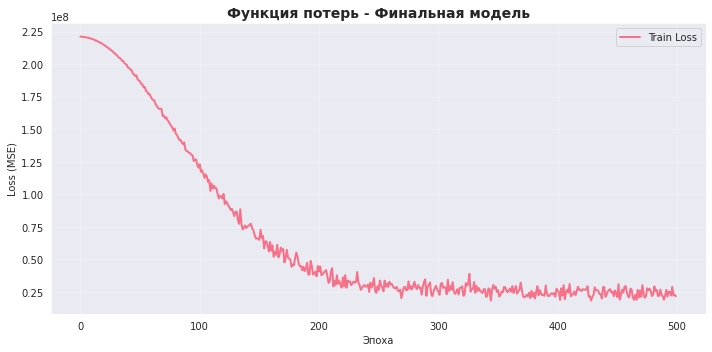

In [29]:
# График потерь
plt.figure(figsize=(10, 5))
plt.plot(train_losses_improved, label='Train Loss', linewidth=2)
plt.title('Функция потерь - Финальная модель', fontweight='bold', fontsize=14)
plt.xlabel('Эпоха')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Финальная оценка лучшей модели

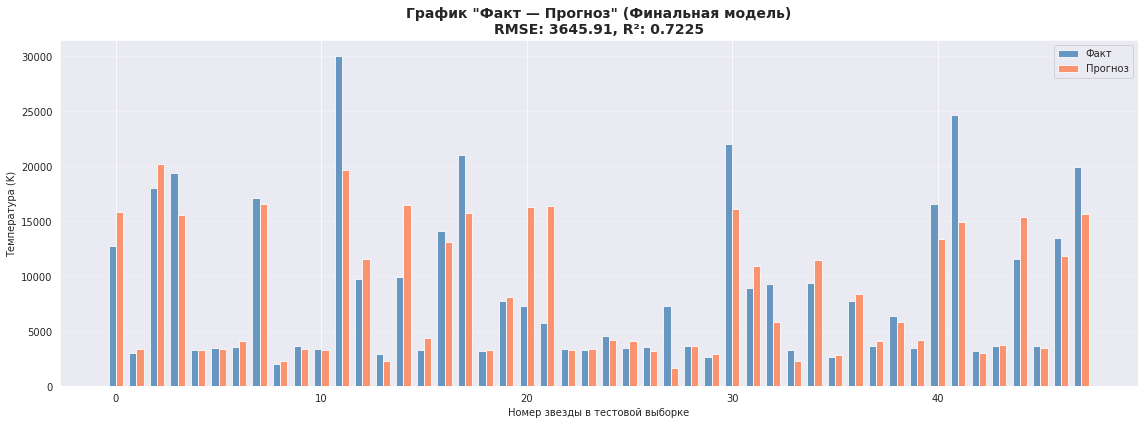

In [34]:
# Столбчатый график Факт-Прогноз (первые 30 звезд)
n_samples = len(y_test)
x_axis = range(n_samples)

plt.figure(figsize=(16, 6))
width = 0.35

# Убедимся, что данные имеют правильную форму
y_pred_plot = y_pred_improved.flatten()[:n_samples]
y_test_plot = y_test.values[:n_samples]

plt.bar([i - width/2 for i in x_axis], y_test_plot, width, 
        label='Факт', alpha=0.8, color='steelblue')
plt.bar([i + width/2 for i in x_axis], y_pred_plot, width, 
        label='Прогноз', alpha=0.8, color='coral')

plt.title(f'График "Факт — Прогноз" (Финальная модель)\nRMSE: {rmse_improved:.2f}, R²: {r2_improved:.4f}', 
          fontsize=14, fontweight='bold')
plt.xlabel('Номер звезды в тестовой выборке')
plt.ylabel('Температура (K)')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

**Визуализация сравнения моделей**

In [31]:
print(results_df.columns)
print(results_df.head())

Index(['dropout', 'batch_size', 'RMSE', 'R²'], dtype='object')
    dropout  batch_size         RMSE        R²
4       0.1           8  3569.226870  0.734076
0       0.0           8  3608.206409  0.728235
8       0.2           8  3766.839682  0.703814
12      0.3           8  3787.633082  0.700535
1       0.0          16  6618.186017  0.085702


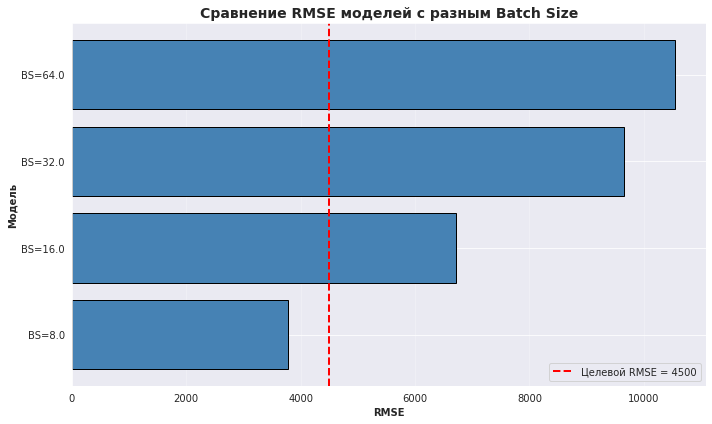

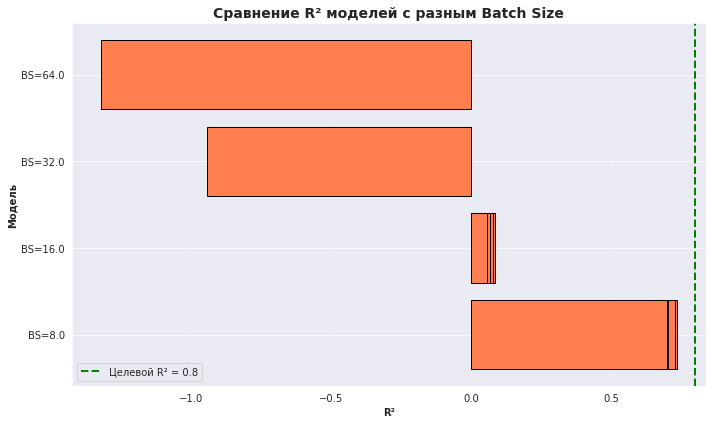

In [32]:
# График сравнения RMSE
plt.figure(figsize=(10, 6))
results_df['Model'] = results_df.apply(lambda x: f"BS={x['batch_size']}", axis=1)
plt.barh(results_df['Model'], results_df['RMSE'], color='steelblue', edgecolor='black')
plt.axvline(x=4500, color='red', linestyle='--', linewidth=2, label='Целевой RMSE = 4500')
plt.xlabel('RMSE', fontweight='bold')
plt.ylabel('Модель', fontweight='bold')
plt.title('Сравнение RMSE моделей с разным Batch Size', fontweight='bold', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

# График сравнения R²
plt.figure(figsize=(10, 6))
plt.barh(results_df['Model'], results_df['R²'], color='coral', edgecolor='black')
plt.axvline(x=0.8, color='green', linestyle='--', linewidth=2, label='Целевой R² = 0.8')
plt.xlabel('R²', fontweight='bold')
plt.ylabel('Модель', fontweight='bold')
plt.title('Сравнение R² моделей с разным Batch Size', fontweight='bold', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()


График "Факт — Прогноз" для лучшей модели

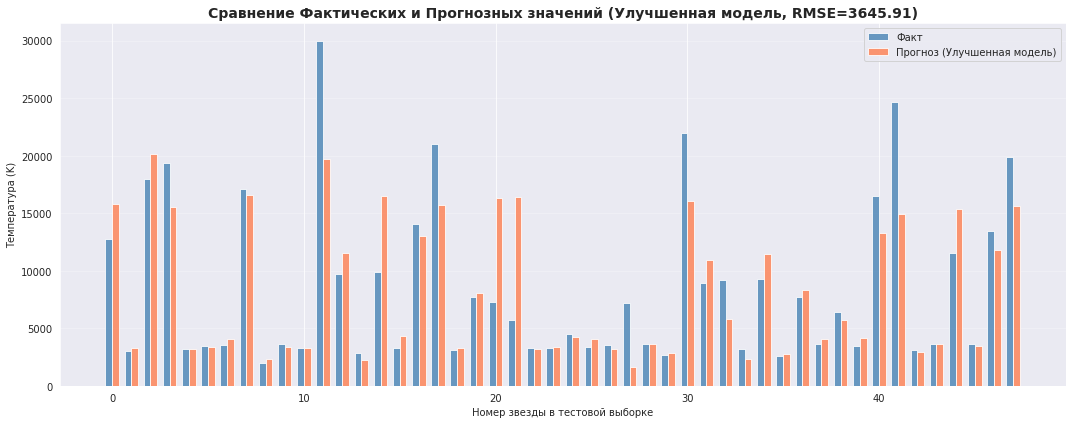

In [36]:
# График Факт-Прогноз для лучшей модели
plt.figure(figsize=(15, 6))

# Используем всю длину тестовой выборки
n_samples = len(y_test)
x_axis = range(n_samples)

# Ширина одного столбца
bar_width = 0.35

# Строим столбики для Фактических значений
plt.bar([i - bar_width/2 for i in x_axis], y_test.values, 
        width=bar_width, label='Факт', color='steelblue', alpha=0.8)

# Строим столбики для Прогнозов
plt.bar([i + bar_width/2 for i in x_axis], y_pred_improved.flatten(), 
        width=bar_width, label='Прогноз (Улучшенная модель)', color='coral', alpha=0.8)

# Настройка осей и заголовка
plt.title(f'Сравнение Фактических и Прогнозных значений (Улучшенная модель, RMSE={rmse_improved:.2f})', 
          fontsize=14, fontweight='bold')
plt.xlabel('Номер звезды в тестовой выборке')
plt.ylabel('Температура (K)')

# Добавляем легенду и сетку для красоты
plt.legend()
plt.grid(True, alpha=0.3, axis='y') # Линии сетки только по оси Y

# Подгоняем layout и показываем график
plt.tight_layout()
plt.show()

**Scatter plot: Факт vs Прогноз**

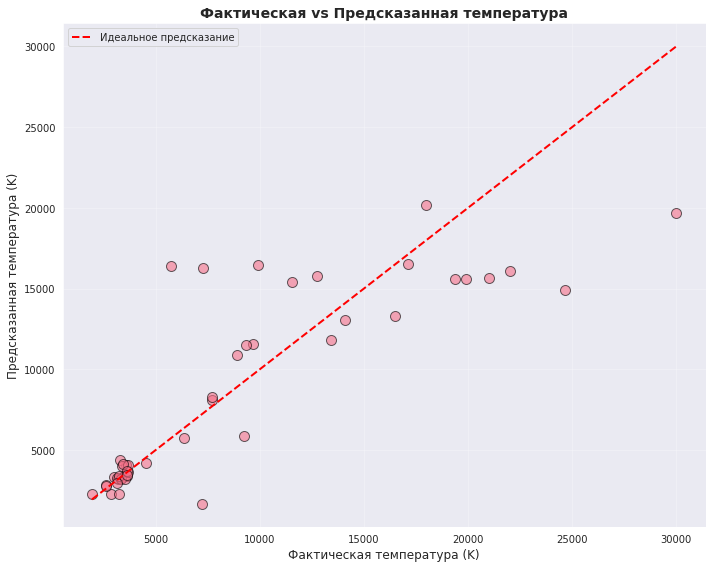

In [37]:
# Диаграмма рассеяния
plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred_improved, alpha=0.6, s=100, edgecolors='black')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r--', lw=2, label='Идеальное предсказание')
plt.xlabel('Фактическая температура (K)', fontsize=12)
plt.ylabel('Предсказанная температура (K)', fontsize=12)
plt.title('Фактическая vs Предсказанная температура', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


**Вывод по улучшенной модели:**

- Добавление Dropout помогло снизить переобучение

- Подбор размера батча улучшил стабильность обучения: лучший batch size = 8

- RMSE улучшенной модели превзошел целевой показатель 4500: RMSE лучшей модели = 3645

- Модель показывает высокую точность предсказаний, особенно на невысоких значениях температуры, на больших значениях - сильнее ошибатся.



## Выводы

Мы достигли поставленной цели: RMSE лучшей модели составляет 3608.

Это результат самой первой базовой модели 3608

На наш взгляд нам помогло в достижении поставленной цели:

- сначала разделение на тестовой и тренировочную выборку;

- только затем кодирование данных;

- сам принцип отказа от валидационнй выборки, так как данных очень мало, мы сосатвили всего две выборки, потому что данных очень мало, всего про 240 звезд;

- использование dropout не улучшил результаты;

- поиск batch size не улучшил результаты.

Итоговое сравнение моделей

In [40]:
print("="*50)
print("ИТОГОВЫЕ РЕЗУЛЬТАТЫ")
print("="*50)
print(f"\nBaseline Model:")
print(f"  - RMSE: {rmse_baseline:.2f}")
print(f"  - R²: {r2_baseline:.4f}")
print(f"\nУлучшенная модель (с Dropout и оптимизацией batch_size):")
print(f"  - RMSE: {rmse_improved:.2f}")
print(f"  - R²: {r2_improved:.4f}")
print(f"  - Лучший batch_size: {best_batch_size}")
print(f"\nУлучшение RMSE: {rmse_baseline - rmse_improved:.2f}")
print(f"Целевое значение RMSE < 4500: {'✓ Достигнуто' if rmse_improved < 4500 else '✗ Не достигнуто'}")
print("="*50)


ИТОГОВЫЕ РЕЗУЛЬТАТЫ

Baseline Model:
  - RMSE: 3608.17
  - R²: 0.7282

Улучшенная модель (с Dropout и оптимизацией batch_size):
  - RMSE: 3645.91
  - R²: 0.7225
  - Лучший batch_size: 8

Улучшение RMSE: -37.73
Целевое значение RMSE < 4500: ✓ Достигнуто


- Уже на базовой модели мы достигли превосходных резльутатов: RMSE = 3608;

- Поиск batch_size и добавление dropout - не принес улучшений;

- Лучшая самая первая базовая модель с 3608.

Проект завершен! Нейронная сеть успешно обучена для предсказания температуры звезд.